In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path 
import re 
import scipy.stats as stats

In [2]:
ls texture_mono_eval

word_task_half_co_loc_v07/  word_task_standard_v08/


In [3]:
texture_manifest  = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/human_experiment_v00/synthetic_textures/manifest.pdpkl')


In [4]:
texture_manifest.head()

,channels,clip_dur_in_s,clip_end_in_s,clip_start_in_s,index_example,index_texture,label,sr,src_fn,src_fn_original,total_file_duration_in_s
0,0,5.0,5.0,0,0,0,16mm_projector,44100,/om2/user/msaddler/spatial_audio_pipeline/asse...,/scratch2/scratch/Wed/salavill/training_sounds...,5.0
1,0,5.0,5.0,0,1,0,16mm_projector,44100,/om2/user/msaddler/spatial_audio_pipeline/asse...,/scratch2/scratch/Wed/salavill/training_sounds...,5.0
2,0,5.0,5.0,0,2,0,16mm_projector,44100,/om2/user/msaddler/spatial_audio_pipeline/asse...,/scratch2/scratch/Wed/salavill/training_sounds...,5.0
3,0,5.0,5.0,0,3,0,16mm_projector,44100,/om2/user/msaddler/spatial_audio_pipeline/asse...,/scratch2/scratch/Wed/salavill/training_sounds...,5.0
4,0,5.0,5.0,0,4,0,16mm_projector,44100,/om2/user/msaddler/spatial_audio_pipeline/asse...,/scratch2/scratch/Wed/salavill/training_sounds...,5.0


In [5]:
# get unique index_texure and labels 

texture_ix_map = {item.index_texture:item.label for item in texture_manifest[['index_texture', 'label']].drop_duplicates().itertuples()}
texture_ix_map

{0: '16mm_projector',
 1: 'airplane_engine',
 2: 'airplane_yout',
 3: 'alarm_bell',
 4: 'applause_large_crowd',
 5: 'applause_small_crowd',
 6: 'bamboo_fountain_yout',
 7: 'bicycle',
 8: 'birdsong_yout',
 9: 'disc_grinder',
 10: 'dolphins',
 11: 'environment_fire_burning_room',
 12: 'environment_fire_inferno',
 13: 'fire_dry_grass',
 14: 'fire_yout',
 15: 'frying_bacon_yout',
 16: 'hand_drill',
 17: 'heavy_traffic_wet_road',
 18: 'hissing_air_1',
 19: 'hissing_air_2',
 20: 'jackhammer_yout',
 21: 'jungle_r',
 22: 'manual_hand_mixer',
 23: 'mechanical_castanets',
 24: 'mechanical_frying_bacon',
 25: 'mechanical_horse_trotting',
 26: 'mechanical_ibm_electric_tyepwriter',
 27: 'mechanical_linotypes',
 28: 'mechanical_metal_lathe',
 29: 'mechanical_shaking_coins',
 30: 'military_jet_on_aircraft_carrier',
 31: 'people_applause_auditorium',
 32: 'people_applause_crowd',
 33: 'rain_in_car_yout',
 34: 'slot_machine',
 35: 'summer_night_yout',
 36: 'teletype_yout',
 37: 'thunder_rain_yout',
 38

In [6]:
# Path to results 
# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations
# match human pilot conditions
# model_name = 'word_task_half_co_loc_v06'
output_paths = list(Path(f"texture_mono_eval/").glob("*/*.csv"))


results_dfs = []

for path in output_paths:
    if any([string in path.stem for string in ['v06', 'more', 'old']]):
        continue
    # res_dict = pickle.load(open(path, 'rb'))
    df = pd.read_csv(path)
    df['model'] = path.parent.stem
    # merge with stim manifest
   
    snr = int(re.search('(-?\d+)dB_SNR', path.stem).group(0).strip('dB_SNR'))
    df['snr'] = snr
    results_dfs.append(df)
results = pd.concat(results_dfs)
results['texture_label'] = results['texture_int'].map(texture_ix_map)

In [7]:
results.head()

,pred_word_int,true_word_int,accuracy,texture_int,model,snr,texture_label
0,710,1,0,0,word_task_half_co_loc_v07,-3,16mm_projector
1,4,4,1,0,word_task_half_co_loc_v07,-3,16mm_projector
2,189,5,0,0,word_task_half_co_loc_v07,-3,16mm_projector
3,624,7,0,0,word_task_half_co_loc_v07,-3,16mm_projector
4,103,8,0,0,word_task_half_co_loc_v07,-3,16mm_projector


In [8]:
results.snr.unique()

array([-3, -6, -9])

In [9]:
grouped_results = results.groupby(['model', 'texture_label', 'snr']).agg({'accuracy':['mean', 'sem']}).reset_index()
# flatten multiindex
grouped_results.columns = ['_'.join(col).strip() for col in grouped_results.columns.values]
# remove trailing underscore
grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_results.columns.values]


# # grouped_results["elevation_cond"] = grouped_results.apply(lambda row: f"target {row.target_elev} distractor {row.distractor_elev}", axis=1)
# grouped_results['elevation_sep'] = grouped_results.target_elev - grouped_results.distractor_elev
# grouped_results['abs_elevation_sep'] = grouped_results.elevation_sep.abs()
# grouped_results['elevated_source'] = grouped_results.elevation_sep.apply(lambda x: 'target' if x > 0 else 'distractor' if x < 0 else 'co-located') 

# grouped_results['abs_target_azim'] = grouped_results.target_azim.abs()
# grouped_results['abs_distractor_azim'] = grouped_results.distractor_azim.abs()

# grouped_results['azim_delta'] = grouped_results.target_azim - grouped_results.distractor_azim
# grouped_results['abs_azim_delta'] = (grouped_results.target_azim - grouped_results.distractor_azim).abs()




In [10]:
### Get human data 

human_df = pd.read_pickle('/om2/user/msaddler/tfauditoryutil/saved_models/HUMAN/spkr_word/human_data_saddler_2023_speech_in_synthetic_textures.pkl')

In [11]:
human_df.head()

,index_texture,snr,correct_word,fn_eval,tag_expt,tag_model
0,0.0,-3.0,0.444444,566a4cf27da0350012b4582d,speech_in_synthetic_textures,human
1,1.0,-3.0,0.555556,566a4cf27da0350012b4582d,speech_in_synthetic_textures,human
2,2.0,-3.0,1.000000,566a4cf27da0350012b4582d,speech_in_synthetic_textures,human
3,3.0,-3.0,0.625000,566a4cf27da0350012b4582d,speech_in_synthetic_textures,human
4,4.0,-3.0,0.444444,566a4cf27da0350012b4582d,speech_in_synthetic_textures,human


In [12]:
human_df['texture_label'] = human_df['index_texture'].map(texture_ix_map)

In [13]:
results.columns

Index(['pred_word_int', 'true_word_int', 'accuracy', 'texture_int', 'model',
       'snr', 'texture_label'],
      dtype='object')

In [14]:
# rename human_df columns to match results
human_df = human_df.rename(columns={'correct_word': 'accuracy', 'tag_model': 'model'})

In [15]:
# merege human and model data
all_results = pd.concat([results[results.snr == -3], human_df])
# rename models and human 
# all_results['model'] = all_results['model'].replace({'human': 'Participants', 'word_task_half_co_loc_v07': 'v07 Model'})
all_results['model'] = all_results['model'].replace({'human': 'Participants'})

In [17]:
all_results.model.unique()

array(['word_task_half_co_loc_v07', 'word_task_standard_v08',
       'Participants'], dtype=object)

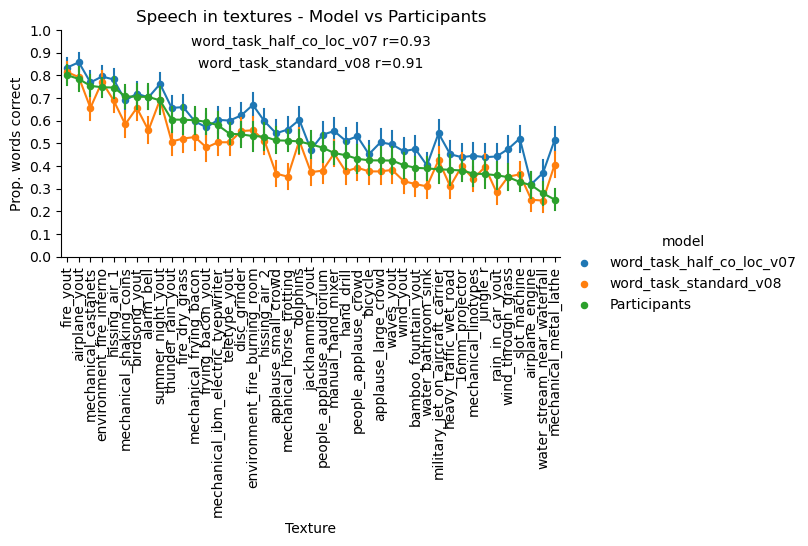

In [21]:
### Compare humans to models 


# order by human accuracy
texture_order = all_results[all_results.model == 'Participants'].groupby('texture_label')['accuracy'].mean().sort_values(ascending=False).index

g = sns.catplot(data=all_results, x='texture_label', y='accuracy', kind='point', order=texture_order,
                hue='model',
                height=3, aspect=2,  errorbar=('se',2), markers='.', linestyles='-')

# change line thickness
for line in g.ax.lines:
    line.set_linewidth(1.5)

g.set(yticks=np.arange(0,  1.1, 0.1))
g.set_xticklabels(rotation=90)
g.set_axis_labels("Texture", "Prop. words correct")
plt.title("Speech in textures - Model vs Participants")

# get pearson correlation between model and human and add to plot
for ix, model in enumerate(['word_task_half_co_loc_v07', 'word_task_standard_v08']):
    model_perf = all_results[all_results.model == model].groupby('texture_label')['accuracy'].mean()
    human_perf = all_results[all_results.model == 'Participants'].groupby('texture_label')['accuracy'].mean()
    r, p = stats.pearsonr(model_perf, human_perf)
    plt.text(0.5, 0.95 - ix * .1, f"{model} r={r:.2f}", ha='center', va='center', transform=g.ax.transAxes)


In [28]:
results.model.unique()

array(['word_task_half_co_loc_v07', 'word_task_standard_v08'],
      dtype=object)

Text(0.5, 1.0, 'Speech in textures - 50% co-located binarual model')

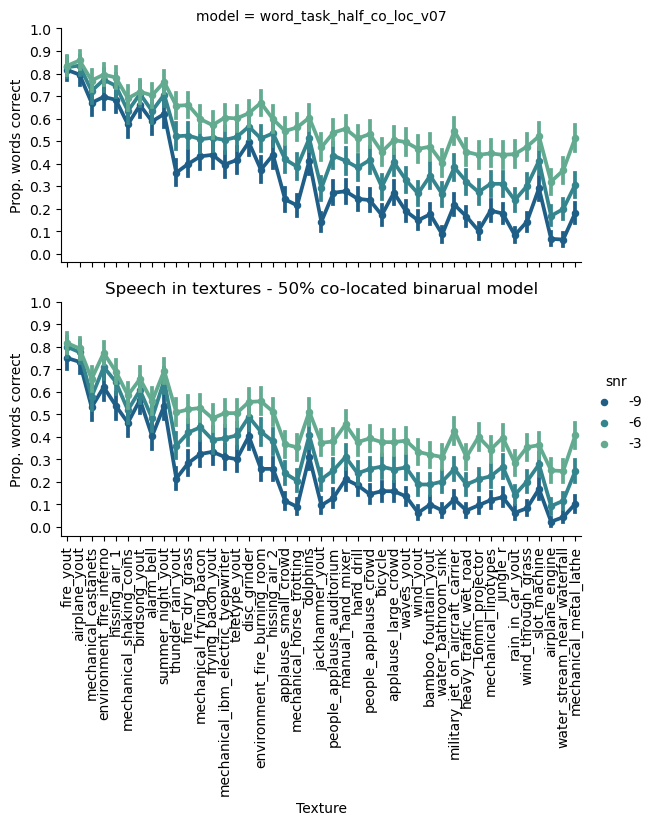

In [26]:

# order textures by accuracy_mean
# texture_order = grouped_results[grouped_results.snr == -3].groupby('texture_label')['accuracy_mean'].mean().sort_values(ascending=False).index
# get color palette based on texture order
palette = sns.color_palette("crest_r", len(grouped_results.snr.unique()))
# create dictionary of texture to color
snr_to_color = {snr: color for snr, color in zip(grouped_results.snr.unique(), palette)}
# map texture to color

# order by mean accuracy
g = sns.catplot(data=results, x='texture_label', y='accuracy', kind='point', 
                hue='snr', palette=snr_to_color, row='model',
                height=3, aspect=2, order=texture_order, errorbar=('se',2), markers='.', linestyles='-')

# change line thickness

# for line in g.ax.lines:
#     line.set_linewidth(1.5)




g.set(yticks=np.arange(0,  1.1, 0.1))
g.set_xticklabels(rotation=90)
g.set_axis_labels("Texture", "Prop. words correct")
plt.title("Speech in textures - 50% co-located binarual model")


In [20]:
human_df.head()

,index_texture,snr,accuracy,fn_eval,tag_expt,model,texture_label
0,0.0,-3.0,0.444444,566a4cf27da0350012b4582d,speech_in_synthetic_textures,human,16mm_projector
1,1.0,-3.0,0.555556,566a4cf27da0350012b4582d,speech_in_synthetic_textures,human,airplane_engine
2,2.0,-3.0,1.000000,566a4cf27da0350012b4582d,speech_in_synthetic_textures,human,airplane_yout
3,3.0,-3.0,0.625000,566a4cf27da0350012b4582d,speech_in_synthetic_textures,human,alarm_bell
4,4.0,-3.0,0.444444,566a4cf27da0350012b4582d,speech_in_synthetic_textures,human,applause_large_crowd


In [39]:
results[results.snr == -3]

,pred_word_int,true_word_int,accuracy,texture_int,model,snr,texture_label
0,710,1,0,0,word_task_half_co_loc_v07,-3,16mm_projector
1,4,4,1,0,word_task_half_co_loc_v07,-3,16mm_projector
2,189,5,0,0,word_task_half_co_loc_v07,-3,16mm_projector
3,624,7,0,0,word_task_half_co_loc_v07,-3,16mm_projector
4,103,8,0,0,word_task_half_co_loc_v07,-3,16mm_projector
...,...,...,...,...,...,...,...
13024,73,787,0,42,word_task_half_co_loc_v07,-3,wind_yout
13025,25,791,0,42,word_task_half_co_loc_v07,-3,wind_yout
13026,83,792,0,42,word_task_half_co_loc_v07,-3,wind_yout
13027,793,793,1,42,word_task_half_co_loc_v07,-3,wind_yout


100%|██████████| 10000/10000 [00:40<00:00, 245.03it/s]


Text(0.5, 1.0, 'Speech in texture performance\nParticipant vs Model')

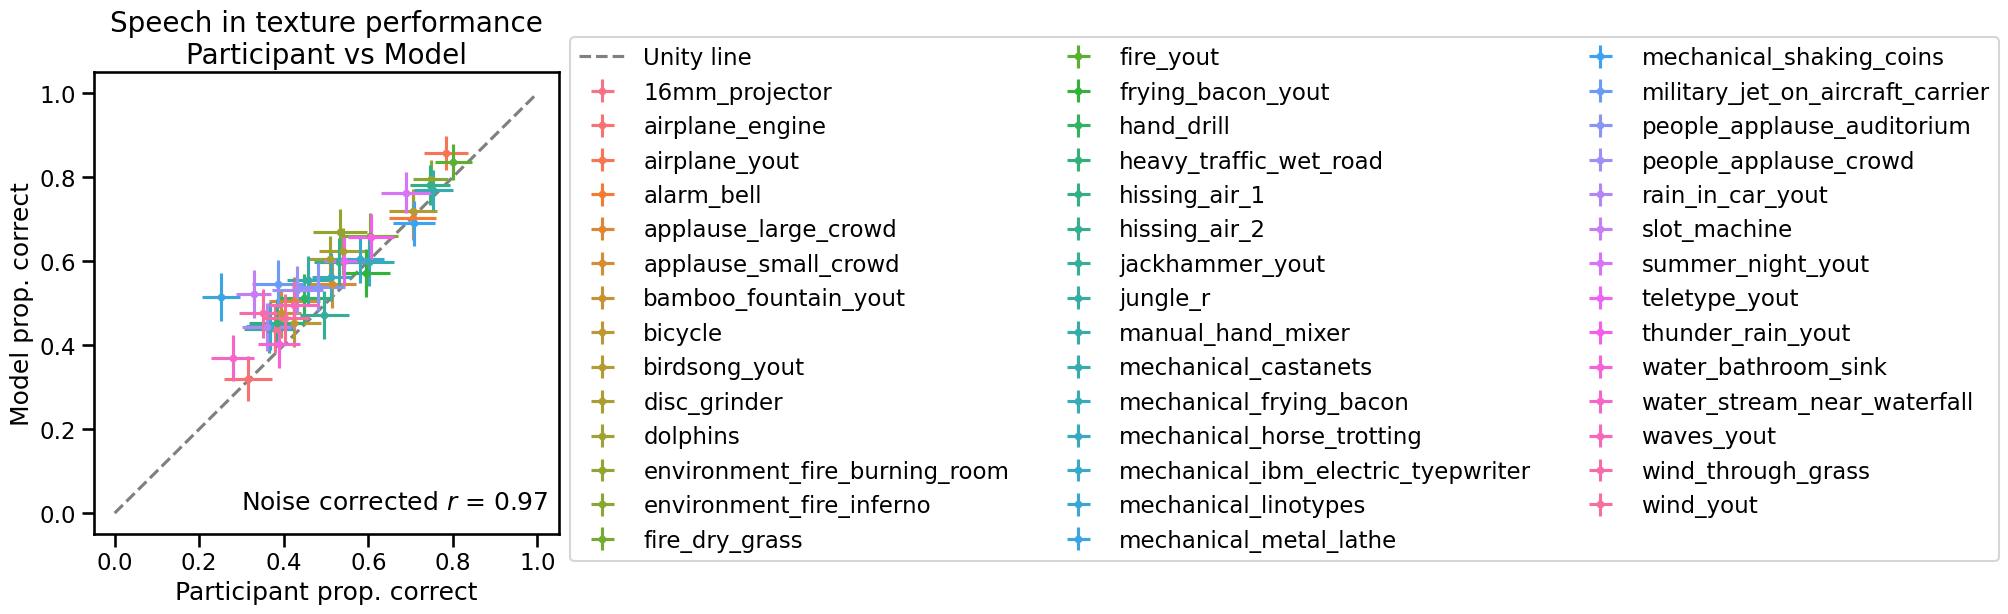

In [29]:
## Compute noise corrected accuracy
# First compute 10,000 split half reliabilities for human data and model data separately    
# Then compute spearman brown correction using averaged reliability  
from tqdm import tqdm

np.random.seed(0)


# split half reliability
def split_half_reliability(data, n_splits=10000):
    reliabilities = np.zeros(n_splits)
    for i in tqdm(range(n_splits)):
        split1 = data.sample(frac=0.5)
        split2 = data.drop(split1.index)
        split1 = split1.groupby('texture_label')['accuracy'].mean().values
        split2 = split2.groupby('texture_label')['accuracy'].mean().values
        r, p = stats.pearsonr(split1, split2)
        reliabilities[i] = r
    mean_r = np.mean(reliabilities)
    split_half_r = (2*mean_r) / (1 + mean_r)
    return split_half_r, reliabilities

hunan_rho, human_reliabilities = split_half_reliability(human_df, n_splits=10000)

model_results_for_comp = results[(results.snr == -3) & (results.model == 'word_task_half_co_loc_v07')]
model_rho, model_reliabilities = split_half_reliability(model_results_for_comp, n_splits=10000)

# means_1 = human_df.groupby('texture_label')['accuracy'].agg(['mean', 'sem'])['mean'].values

human_perf = human_df.groupby('texture_label')['accuracy'].agg(['mean', 'sem']).reset_index()
model_perf = model_results_for_comp.groupby('texture_label')['accuracy'].agg(['mean', 'sem']).reset_index()
r_model_human, p = stats.pearsonr(model_perf['mean'].values, human_perf['mean'].values)

# spearman brown correction
spearman_brown_r = r_model_human / np.sqrt(hunan_rho * model_rho)

sns.set_context('talk')
# plot human performance against model performance
fig, axs =  plt.subplots(1,1, figsize=(6,6))
fontsize=18
# make  palette for texture labels
palette = sns.color_palette("husl", len(human_perf))

x = y = np.linspace(0,1,5)

# plot data with 2 sem error bars
axs.plot(x,y, ls='dashed', color='grey', label='Unity line')

for i, row in human_perf.iterrows():
    axs.errorbar(x=row['mean'], y=model_perf.iloc[i]['mean'],
              xerr = row['sem']*2, yerr=model_perf.iloc[i]['sem']*2, fmt='.', 
              label=row['texture_label'],
              color=palette[i])
            # marker='o', linestyle=None, ms=3, elinewidth=2.5,)
# axs.errorbar(x=human_perf['mean'], y=model_perf['mean'],
#               xerr = human_perf['sem']*2, yerr=model_perf['sem']*2, fmt='.', 
#               label=human_perf['texture_label'])
            # marker='o', linestyle=None, ms=3, elinewidth=2.5,)
axs.set_xlabel('Participant prop. correct')
axs.set_ylabel('Model prop. correct')

# add correlation as text
axs.annotate(f"Noise corrected $r$ = {spearman_brown_r:.2f}", (0.3, 0.01), fontsize=fontsize)


# add legend
axs.legend( loc='upper left', ncol=3, bbox_to_anchor=(1,1.1))
plt.title("Speech in texture performance\nParticipant vs Model", fontsize=fontsize+2) 



  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:41<00:00, 238.63it/s]


Text(0.5, 1.0, 'Speech in texture performance\nParticipant vs Model')

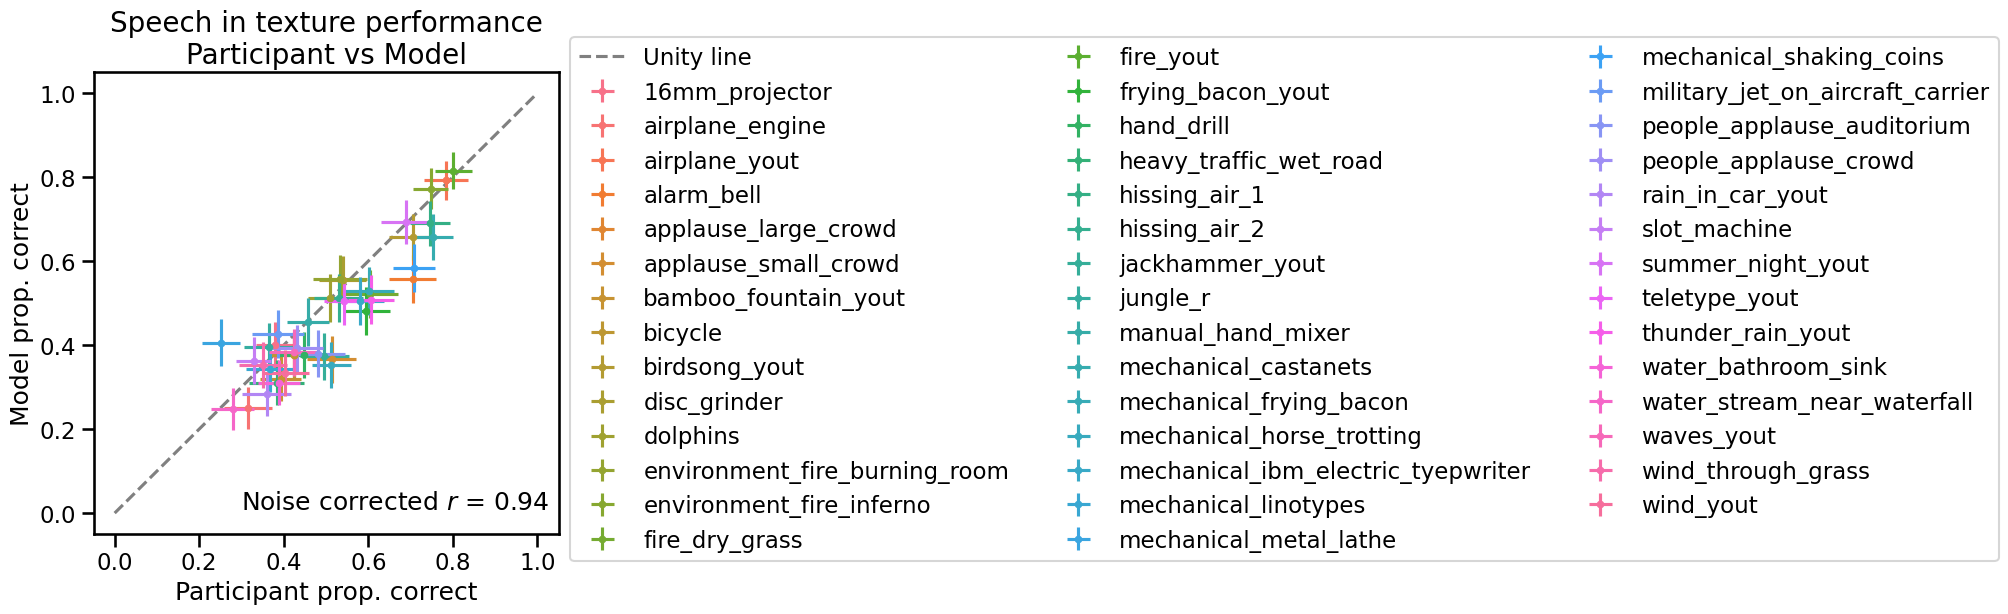

In [33]:
## Compute noise corrected accuracy
# First compute 10,000 split half reliabilities for human data and model data separately    
# Then compute spearman brown correction using averaged reliability  
from tqdm import tqdm

np.random.seed(0)


# split half reliability
def split_half_reliability(data, n_splits=10000):
    reliabilities = np.zeros(n_splits)
    for i in tqdm(range(n_splits)):
        split1 = data.sample(frac=0.5)
        split2 = data.drop(split1.index)
        split1 = split1.groupby('texture_label')['accuracy'].mean().values
        split2 = split2.groupby('texture_label')['accuracy'].mean().values
        r, p = stats.pearsonr(split1, split2)
        reliabilities[i] = r
    mean_r = np.mean(reliabilities)
    split_half_r = (2*mean_r) / (1 + mean_r)
    return split_half_r, reliabilities

# hunan_rho, human_reliabilities = split_half_reliability(human_df, n_splits=10000)

model_results_for_comp = results[(results.snr == -3) & (results.model == 'word_task_standard_v08')]
model_rho, model_reliabilities = split_half_reliability(model_results_for_comp, n_splits=10000)

# means_1 = human_df.groupby('texture_label')['accuracy'].agg(['mean', 'sem'])['mean'].values

human_perf = human_df.groupby('texture_label')['accuracy'].agg(['mean', 'sem']).reset_index()
model_perf = model_results_for_comp.groupby('texture_label')['accuracy'].agg(['mean', 'sem']).reset_index()
r_model_human, p = stats.pearsonr(model_perf['mean'].values, human_perf['mean'].values)

# spearman brown correction
spearman_brown_r = r_model_human / np.sqrt(hunan_rho * model_rho)

sns.set_context('talk')
# plot human performance against model performance
fig, axs =  plt.subplots(1,1, figsize=(6,6))
fontsize=18
# make  palette for texture labels
palette = sns.color_palette("husl", len(human_perf))

x = y = np.linspace(0,1,5)

# plot data with 2 sem error bars
axs.plot(x,y, ls='dashed', color='grey', label='Unity line')

for i, row in human_perf.iterrows():
    axs.errorbar(x=row['mean'], y=model_perf.iloc[i]['mean'],
              xerr = row['sem']*2, yerr=model_perf.iloc[i]['sem']*2, fmt='.', 
              label=row['texture_label'],
              color=palette[i])
            # marker='o', linestyle=None, ms=3, elinewidth=2.5,)
# axs.errorbar(x=human_perf['mean'], y=model_perf['mean'],
#               xerr = human_perf['sem']*2, yerr=model_perf['sem']*2, fmt='.', 
#               label=human_perf['texture_label'])
            # marker='o', linestyle=None, ms=3, elinewidth=2.5,)
axs.set_xlabel('Participant prop. correct')
axs.set_ylabel('Model prop. correct')

# add correlation as text
axs.annotate(f"Noise corrected $r$ = {spearman_brown_r:.2f}", (0.3, 0.01), fontsize=fontsize)


# add legend
axs.legend( loc='upper left', ncol=3, bbox_to_anchor=(1,1.1))
plt.title("Speech in texture performance\nParticipant vs Model", fontsize=fontsize+2) 



In [31]:
model_results_for_comp

,pred_word_int,true_word_int,accuracy,texture_int,model,snr,texture_label


Text(0.5, 1.0, 'Speech in texture performance\nParticipant vs Model')

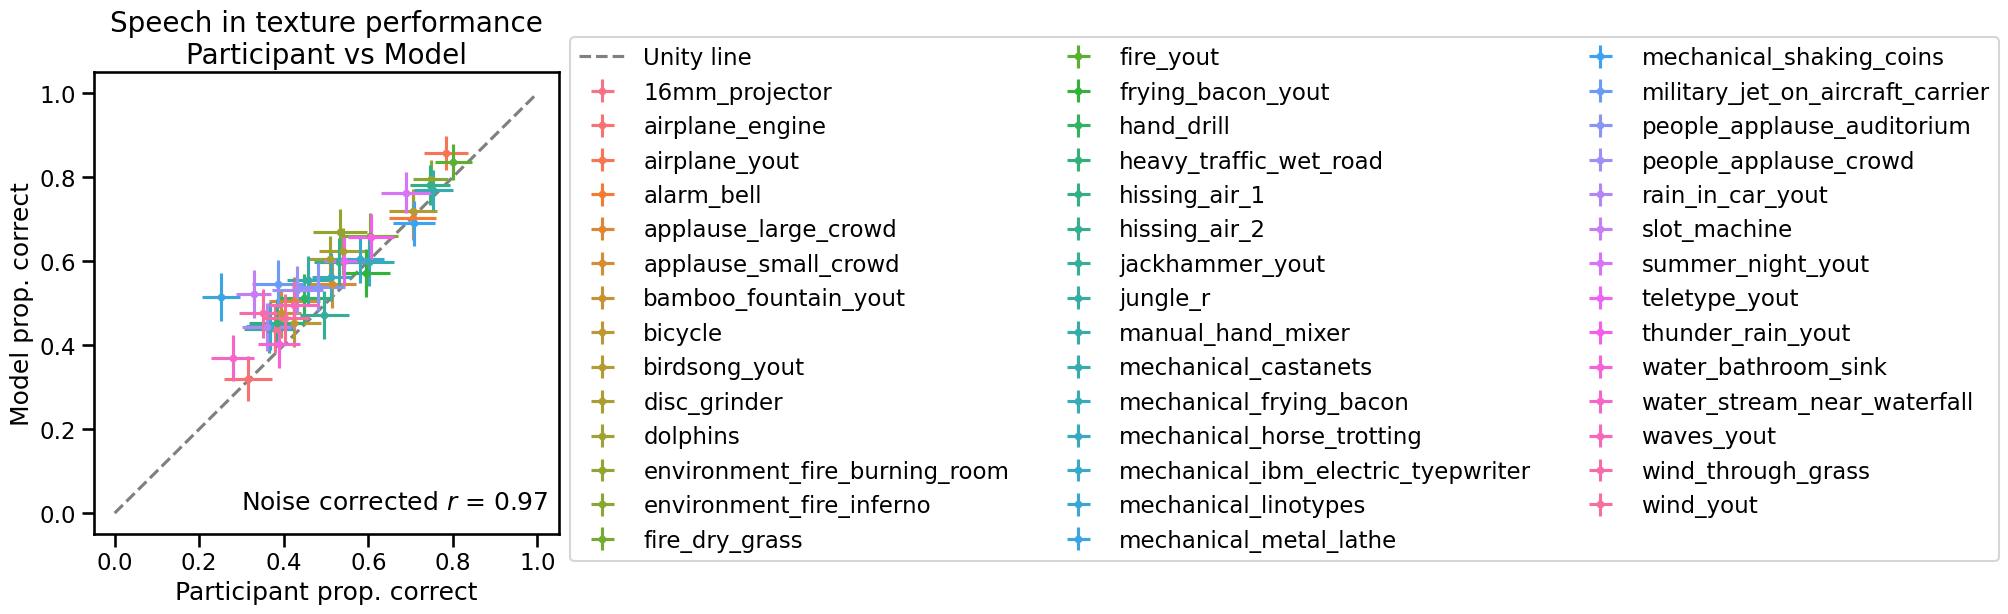

In [120]:
human_perf = human_df.groupby('texture_label')['accuracy'].agg(['mean', 'sem']).reset_index()
model_perf = model_results_for_comp.groupby('texture_label')['accuracy'].agg(['mean', 'sem']).reset_index()
r_model_human, p = stats.pearsonr(model_perf['mean'].values, human_perf['mean'].values)

# spearman brown correction
spearman_brown_r = r_model_human / np.sqrt(hunan_rho * model_rho)

sns.set_context('talk')
# plot human performance against model performance
fig, axs =  plt.subplots(1,1, figsize=(6,6))
fontsize=18
# make  palette for texture labels
palette = sns.color_palette("husl", len(human_perf))

x = y = np.linspace(0,1,5)

# plot data with 2 sem error bars
axs.plot(x,y, ls='dashed', color='grey', label='Unity line')

for i, row in human_perf.iterrows():
    axs.errorbar(x=row['mean'], y=model_perf.iloc[i]['mean'],
              xerr = row['sem']*2, yerr=model_perf.iloc[i]['sem']*2, fmt='.', 
              label=row['texture_label'],
              color=palette[i])
            # marker='o', linestyle=None, ms=3, elinewidth=2.5,)
# axs.errorbar(x=human_perf['mean'], y=model_perf['mean'],
#               xerr = human_perf['sem']*2, yerr=model_perf['sem']*2, fmt='.', 
#               label=human_perf['texture_label'])
            # marker='o', linestyle=None, ms=3, elinewidth=2.5,)
axs.set_xlabel('Participant prop. correct')
axs.set_ylabel('Model prop. correct')

# add correlation as text
axs.annotate(f"Noise corrected $r$ = {spearman_brown_r:.2f}", (0.3, 0.01), fontsize=fontsize)


# add legend
axs.legend( loc='upper left', ncol=3, bbox_to_anchor=(1,1.1))
plt.title("Speech in texture performance\nParticipant vs Model", fontsize=fontsize+2) 


In [91]:
human_perf['texture_label'].values

array(['16mm_projector', 'airplane_engine', 'airplane_yout', 'alarm_bell',
       'applause_large_crowd', 'applause_small_crowd',
       'bamboo_fountain_yout', 'bicycle', 'birdsong_yout', 'disc_grinder',
       'dolphins', 'environment_fire_burning_room',
       'environment_fire_inferno', 'fire_dry_grass', 'fire_yout',
       'frying_bacon_yout', 'hand_drill', 'heavy_traffic_wet_road',
       'hissing_air_1', 'hissing_air_2', 'jackhammer_yout', 'jungle_r',
       'manual_hand_mixer', 'mechanical_castanets',
       'mechanical_frying_bacon', 'mechanical_horse_trotting',
       'mechanical_ibm_electric_tyepwriter', 'mechanical_linotypes',
       'mechanical_metal_lathe', 'mechanical_shaking_coins',
       'military_jet_on_aircraft_carrier', 'people_applause_auditorium',
       'people_applause_crowd', 'rain_in_car_yout', 'slot_machine',
       'summer_night_yout', 'teletype_yout', 'thunder_rain_yout',
       'water_bathroom_sink', 'water_stream_near_waterfall', 'waves_yout',
       'wi

0.9653483135716678


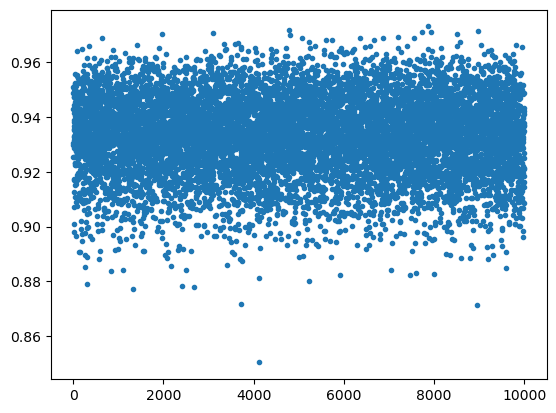

In [38]:
plt.plot(human_reliabilities, '.')
print(hunan_rho)

In [33]:
human_mean = np.mean(human_reliabilities)